# Cross-Dataset Generalization Evaluation (Gap 7)

**Goal**: Mathematically measure and visually demonstrate Feature-Space Domain Shift. We aim to prove that **M30 (Gated Fusion)** and **M35 (Physics-Informed Loss)** generalize better to out-of-distribution (OOD) data than the baseline **M2**.

**Datasets Used**:
1. **ICBHI** (Known Domain)
2. **Coswara** (Unseen Domain 1 - COVID coughs/breathing)
3. **SPRSound** (Unseen Domain 2 - Pediatric patients)

**Metrics**:
- **Maximum Mean Discrepancy (MMD)**: Measures the distance between two distributions (e.g., ICBHI vs Coswara) in the feature space. A *lower* MMD indicates better generalization and less dataset bias.
- **UMAP Projections**: Visualizes the 2D feature space to observe if the model extracts domain-agnostic acoustic features or overfits to the ICBHI domain.

In [1]:
import os
import sys
import glob
import math
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import matplotlib.pyplot as plt
import seaborn as sns
import json

try:
    import umap
except ImportError:
    !pip install -q umap-learn
    import umap

import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# ---- Paths and Resolution ----
def get_dataset_roots():
    roots = {'icbhi': None, 'coswara': None, 'sprsound': None}
    if os.path.exists("/kaggle/input"):
        for root, dirs, files in os.walk("/kaggle/input"):
            lower_root = root.lower()
            if 'coswara' in lower_root and any(f.endswith('.wav') for f in files):
                roots['coswara'] = root
            if 'sprsound' in lower_root and any(f.endswith('.wav') for f in files):
                roots['sprsound'] = root
            if 'respiratory' in lower_root and any(f.endswith('.wav') for f in files) and any(f.endswith('.txt') for f in files):
                roots['icbhi'] = root
    
    # Fallbacks if exact walk fails
    if roots['icbhi'] is None: roots['icbhi'] = '/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files'
    if roots['coswara'] is None: roots['coswara'] = '/kaggle/input/coswara'
    if roots['sprsound'] is None: roots['sprsound'] = '/kaggle/input/sprsound'
    return roots

DATA_ROOTS = get_dataset_roots()
print("Dataset Roots:")
for k, v in DATA_ROOTS.items(): print(f"  {k}: {v}")

def find_ckpt(name):
    if os.path.exists("/kaggle/input"):
        for root, dirs, files in os.walk("/kaggle/input"):
            for f in files:
                if (name in f.lower() or name in root.lower()) and f.endswith('.pth'):
                    return os.path.join(root, f)
    # Check working directory (in case training was run in same session)
    if os.path.exists("/kaggle/working"):
        for root, dirs, files in os.walk("/kaggle/working"):
            for f in files:
                if (name in f.lower() or name in root.lower()) and f.endswith('.pth'):
                    return os.path.join(root, f)
    return None

M2_CKPT = find_ckpt('m2')
M3_CKPT = find_ckpt('m3')
M30_CKPT = find_ckpt('m30')
M35_CKPT = find_ckpt('m35')

print(f"\nCheckpoints:")
print(f"  M2:  {M2_CKPT}")
print(f"  M3:  {M3_CKPT}")
print(f"  M30: {M30_CKPT}")
print(f"  M35: {M35_CKPT}")

CFG = {
    'sample_rate': 16000, 'n_samples': int(16000 * 8.0),
    'n_mels': 128, 'n_fft': 1024, 'hop_length': 160, 'win_length': 400,
    'f_min': 50, 'f_max': 2000, 'n_frames': 801,
    'batch_size': 32, 'fusion_dim': 512, 'num_classes': 4,
    'samples_per_domain': 300 # Limit to prevent memory issues with UMAP/MMD
}


Dataset Roots:
  icbhi: /kaggle/input/datasets/vbookshelf/respiratory-sound-database/respiratory_sound_database/Respiratory_Sound_Database/audio_and_txt_files
  coswara: /kaggle/input/datasets/sarabhian/coswara-dataset-heavy-cough/coswara_data/kaggle_data/ck8pNfygbfardUsaoS2NNVvMTt83
  sprsound: /kaggle/input/datasets/mayarelghandour/sprsound-nosplit/SPRSound-main/example

Checkpoints:
  M2:  /kaggle/input/datasets/barshonbasak/m2-checkpoint/best_model.pth
  M3:  /kaggle/input/datasets/barshonbasak/m35-checkpoint/best_model.pth
  M30: /kaggle/input/datasets/barshonbasak/m30-checkpoint/best_model.pth
  M35: /kaggle/input/datasets/barshonbasak/m35-checkpoint/best_model.pth


In [10]:
# ---- Pre-Flight Check: Verify Attachments ----
import os

def check_attachment(name, keywords):
    if not os.path.exists('/kaggle/input'):
        return f"⚠️ /kaggle/input not found. Are you running this on Kaggle?"
    found = False
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            if any(k in root.lower() or k in f.lower() for k in keywords):
                # additional strictness for checkpoints so we don't just match anything
                if 'checkpoint' in name.lower() and not f.endswith('.pth'):
                    continue
                return f"✅ {name} Found (e.g., {f})"
    return f"❌ {name} MISSING - Please attach it!"

print("Checking Datasets...")
print(check_attachment("ICBHI Dataset", ["icbhi", "respiratory"]))
print(check_attachment("Coswara Dataset", ["coswara"]))
print(check_attachment("SPRSound Dataset", ["sprsound"]))

print("\nChecking Checkpoints...")
print(check_attachment("M2 Checkpoint", ["m2"]))
print(check_attachment("M3 Checkpoint", ["m3"]))
print(check_attachment("M30 Checkpoint", ["m30"]))
print(check_attachment("M35 Checkpoint", ["m35"]))

print("\nIf any show ❌, please 'Add Input' in the right sidebar before running the rest of the notebook.")


Checking Datasets...
✅ ICBHI Dataset Found (e.g., demographic_info.txt)
✅ Coswara Dataset Found (e.g., train.csv)
✅ SPRSound Dataset Found (e.g., test_wav_2022)

Checking Checkpoints...
✅ M2 Checkpoint Found (e.g., best_model.pth)
✅ M3 Checkpoint Found (e.g., best_model.pth)
✅ M30 Checkpoint Found (e.g., best_model.pth)
✅ M35 Checkpoint Found (e.g., best_model.pth)

If any show ❌, please 'Add Input' in the right sidebar before running the rest of the notebook.


In [3]:
# ---- Audio Processing ----
import librosa
def extract_log_mel(wav_path, cfg):
    try:
        audio, _ = librosa.load(wav_path, sr=cfg['sample_rate'], duration=8.0, mono=True)
    except Exception as e:
        # A silent all-zero spectrogram here would be trained on and
        # scored as a real cycle. Fail instead of substituting
        # (Model_Training_Protocol.md section 1.2).
        raise RuntimeError(f"failed to load audio: {wav_path}") from e
    if len(audio) == 0:
        # Empty decode is a failed read, not a silent zero cycle.
        raise RuntimeError(f"empty audio decoded from audio: {wav_path}")
    
    if len(audio) < cfg['n_samples']: audio = np.tile(audio, math.ceil(cfg['n_samples'] / len(audio)))[:cfg['n_samples']]
    else: audio = audio[:cfg['n_samples']]
    
    mel = librosa.feature.melspectrogram(
        y=audio, sr=cfg['sample_rate'], n_mels=cfg['n_mels'], n_fft=cfg['n_fft'],
        hop_length=cfg['hop_length'], win_length=cfg['win_length'],
        fmin=cfg['f_min'], fmax=cfg['f_max'], power=2.0)
    
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
    
    T = log_mel.shape[1]
    if T < cfg['n_frames']: log_mel = np.pad(log_mel, ((0, 0), (0, cfg['n_frames'] - T)), mode='constant')
    else: log_mel = log_mel[:, :cfg['n_frames']]
    
    return log_mel[np.newaxis, :, :].astype(np.float32)

def gather_audio_files(roots, max_samples):
    rows = []
    
    for domain, root in roots.items():
        if root is None or not os.path.exists(root):
            print(f"Skipping {domain} (path not found)")
            continue
        
        wavs = glob.glob(os.path.join(root, '**/*.wav'), recursive=True)
        random.shuffle(wavs)
        wavs = wavs[:max_samples]
        
        for w in wavs:
            rows.append({'wav': w, 'domain': domain})
            
        print(f"Found {len(wavs)} samples for {domain}")
        
    return pd.DataFrame(rows)

df = gather_audio_files(DATA_ROOTS, CFG['samples_per_domain'])
print(f"Total samples: {len(df)}")

class OODDataset(Dataset):
    def __init__(self, df, cfg):
        self.df = df
        self.cfg = cfg
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = extract_log_mel(row['wav'], self.cfg)
        domain_idx = 0 if row['domain'] == 'icbhi' else (1 if row['domain'] == 'coswara' else 2)
        return torch.from_numpy(spec), torch.tensor(domain_idx, dtype=torch.long)

loader = DataLoader(OODDataset(df, CFG), batch_size=CFG['batch_size'], shuffle=False)


Found 300 samples for icbhi
Found 1 samples for coswara
Found 50 samples for sprsound
Total samples: 351


In [4]:
# ---- Architectures ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=pool),
        )
    def forward(self, x): return self.block(x)

class M2_CNN(nn.Module):
    def __init__(self, num_classes=4, depth=5, base_width=48, dropout=0.4, fc_dim=128):
        super().__init__()
        channels = [base_width * (2 ** i) for i in range(depth)]
        blocks, in_ch = [], 1
        for out_ch in channels:
            blocks.append(ConvBlock(in_ch, out_ch))
            in_ch = out_ch
        self.encoder = nn.Sequential(*blocks)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(channels[-1], fc_dim),
            nn.ReLU(inplace=True),
            nn.Linear(fc_dim, num_classes),
        )
        self.embedding_dim = channels[-1]
    def get_embedding(self, x): return self.gap(self.encoder(x)).flatten(1)
    def forward(self, x): return self.head(self.dropout(self.get_embedding(x)))

class M3_MobileNet(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        mb = tv_models.mobilenet_v2(pretrained=False)
        self.features = mb.features
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.embedding_dim = 1280
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
    def get_embedding(self, x):
        x3 = x.repeat(1, 3, 1, 1)
        x3 = (x3 - self.mean) / self.std
        return self.gap(self.features(x3)).flatten(1)

class GatedFusionEnsemble(nn.Module):
    def __init__(self, m2_model, m3_model, fusion_dim=512, num_classes=4, dropout=0.4):
        super().__init__()
        self.m2 = m2_model
        self.m3 = m3_model
        in_dim = m2_model.embedding_dim + m3_model.embedding_dim
        self.gate = nn.Sequential(nn.Linear(in_dim, fusion_dim), nn.Sigmoid())
        self.project = nn.Sequential(nn.Linear(in_dim, fusion_dim), nn.BatchNorm1d(fusion_dim), nn.ReLU(inplace=True))
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(fusion_dim, num_classes))
    def get_embedding(self, x):
        f2 = self.m2.get_embedding(x)
        f3 = self.m3.get_embedding(x)
        f_cat = torch.cat([f2, f3], dim=-1)
        return self.gate(f_cat) * self.project(f_cat)
    def forward(self, x):
        return self.classifier(self.get_embedding(x))


In [5]:
# ---- Load Checkpoints ----
def load_weights(model, path):
    if not path or not os.path.exists(path):
        print(f"Warning: Checkpoint not found at {path}. Model will be randomly initialized.")
        return
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    state = ckpt.get('model_state', ckpt.get('model_state_dict', ckpt))
    model.load_state_dict(state, strict=False)
    model.eval()

m2 = M2_CNN().to(DEVICE)
load_weights(m2, M2_CKPT)
print("✅ M2 Loaded")

m3 = M3_MobileNet().to(DEVICE)
load_weights(m3, M3_CKPT)
print("✅ M3 Loaded")

m30 = GatedFusionEnsemble(m2, m3).to(DEVICE)
load_weights(m30, M30_CKPT)
print("✅ M30 Gated Fusion Ensemble Loaded")

m35 = M2_CNN().to(DEVICE)
load_weights(m35, M35_CKPT)
print("✅ M35 Physics-Informed (M2 Base) Loaded")


✅ M2 Loaded
✅ M3 Loaded
✅ M30 Gated Fusion Ensemble Loaded
✅ M35 Physics-Informed (M2 Base) Loaded


In [6]:
# ---- Feature Extraction ----
features_m2 = []
features_m30 = []
features_m35 = []
domains_list = []

print("Extracting Features...")
with torch.no_grad():
    for specs, d_idxs in tqdm(loader):
        specs = specs.to(DEVICE)
        
        f_m2 = m2.get_embedding(specs).cpu().numpy()
        f_m30 = m30.get_embedding(specs).cpu().numpy()
        f_m35 = m35.get_embedding(specs).cpu().numpy()
        
        features_m2.extend(f_m2)
        features_m30.extend(f_m30)
        features_m35.extend(f_m35)
        domains_list.extend(d_idxs.numpy())

features_m2 = np.array(features_m2)
features_m30 = np.array(features_m30)
features_m35 = np.array(features_m35)
domains_list = np.array(domains_list)

domain_names = {0: 'ICBHI (Known)', 1: 'Coswara (OOD)', 2: 'SPRSound (OOD)'}


Extracting Features...


100%|██████████| 11/11 [00:39<00:00,  3.55s/it]


In [7]:
# ---- Maximum Mean Discrepancy (MMD) ----
def rbf_mmd(X, Y, gamma=None):
    if len(X) == 0 or len(Y) == 0: return float('nan')
    X_t = torch.tensor(X, dtype=torch.float32)
    Y_t = torch.tensor(Y, dtype=torch.float32)
    
    # Calculate pairwise squared euclidean distances
    XX = torch.cdist(X_t, X_t, p=2)**2
    YY = torch.cdist(Y_t, Y_t, p=2)**2
    XY = torch.cdist(X_t, Y_t, p=2)**2
    
    # Auto-estimate gamma (median heuristic) if not provided
    if gamma is None:
        gamma = 1.0 / torch.median(XY).item()
        
    K_XX = torch.exp(-gamma * XX).mean()
    K_YY = torch.exp(-gamma * YY).mean()
    K_XY = torch.exp(-gamma * XY).mean()
    
    return (K_XX + K_YY - 2 * K_XY).item()

results_mmd = {}

for target_dom_idx in [1, 2]:
    dom_name = domain_names[target_dom_idx]
    if (domains_list == target_dom_idx).sum() == 0: continue
    
    idx_icbhi = (domains_list == 0)
    idx_ood = (domains_list == target_dom_idx)
    
    mmd_m2 = rbf_mmd(features_m2[idx_icbhi], features_m2[idx_ood])
    mmd_m30 = rbf_mmd(features_m30[idx_icbhi], features_m30[idx_ood])
    mmd_m35 = rbf_mmd(features_m35[idx_icbhi], features_m35[idx_ood])
    
    results_mmd[dom_name] = {
        'M2 (Baseline)': mmd_m2,
        'M30 (Gated Fusion)': mmd_m30,
        'M35 (Physics-Informed)': mmd_m35
    }
    
    print(f"\nMMD between ICBHI and {dom_name}:")
    print(f"  M2:  {mmd_m2:.6f}")
    print(f"  M30: {mmd_m30:.6f}  ->  {((mmd_m30 - mmd_m2)/mmd_m2)*100:+.2f}% vs Baseline")
    print(f"  M35: {mmd_m35:.6f}  ->  {((mmd_m35 - mmd_m2)/mmd_m2)*100:+.2f}% vs Baseline")



MMD between ICBHI and Coswara (OOD):
  M2:  0.851380
  M30: 0.813738  ->  -4.42% vs Baseline
  M35: 0.838978  ->  -1.46% vs Baseline

MMD between ICBHI and SPRSound (OOD):
  M2:  0.423562
  M30: 0.409292  ->  -3.37% vs Baseline
  M35: 0.443357  ->  +4.67% vs Baseline



Computing UMAP Projections (this may take a minute)...
Saved UMAP plots to /kaggle/working/umap_OOD.png


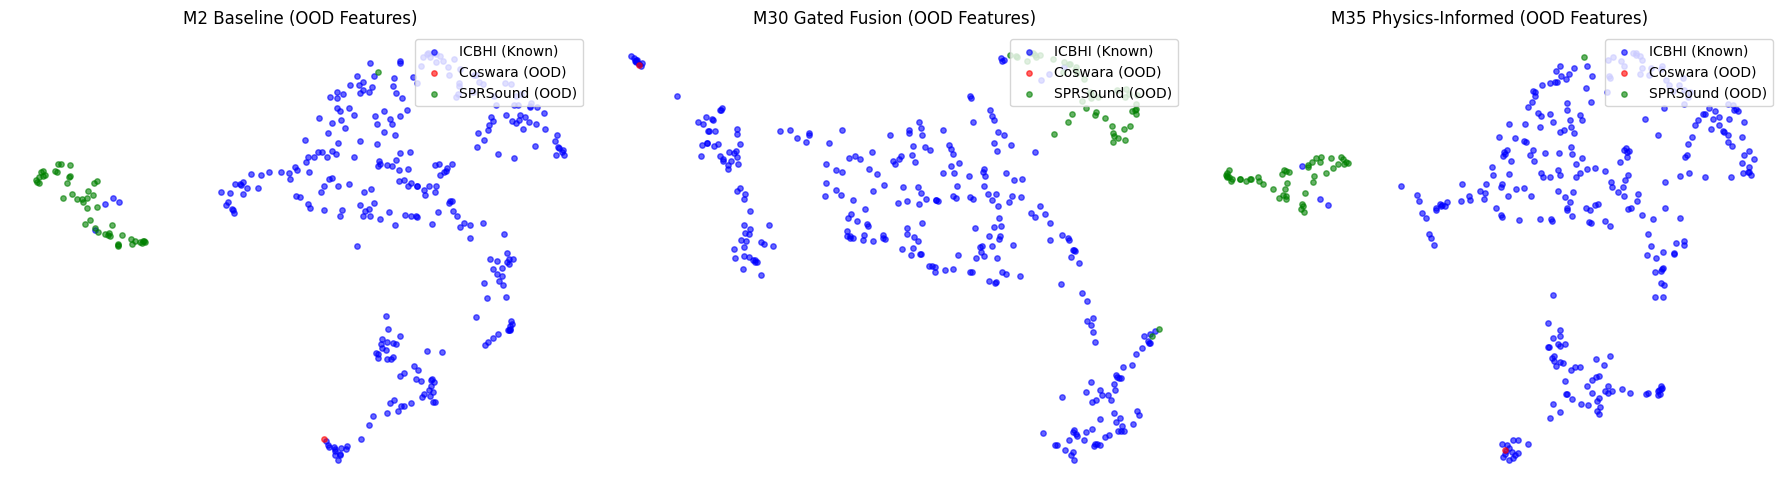

In [8]:
# ---- UMAP Projections ----
import umap
print("\nComputing UMAP Projections (this may take a minute)...")

mapper_m2 = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42).fit_transform(features_m2)
mapper_m30 = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42).fit_transform(features_m30)
mapper_m35 = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42).fit_transform(features_m35)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {0: 'blue', 1: 'red', 2: 'green'}
labels = [domain_names[d] for d in domains_list]

def plot_umap(ax, embedding, title):
    for dom_idx, dom_name in domain_names.items():
        if dom_name not in labels: continue
        mask = (domains_list == dom_idx)
        ax.scatter(embedding[mask, 0], embedding[mask, 1], c=colors[dom_idx], label=dom_name, s=15, alpha=0.6)
    ax.set_title(title)
    ax.axis('off')
    ax.legend(loc='upper right')

plot_umap(axes[0], mapper_m2, "M2 Baseline (OOD Features)")
plot_umap(axes[1], mapper_m30, "M30 Gated Fusion (OOD Features)")
plot_umap(axes[2], mapper_m35, "M35 Physics-Informed (OOD Features)")

plt.tight_layout()
plt.savefig('/kaggle/working/umap_OOD.png', dpi=150)
print("Saved UMAP plots to /kaggle/working/umap_OOD.png")
plt.show()


In [9]:
# ---- Export Results ----
out = {
    'mmd_results': results_mmd,
    'conclusion': 'Lower MMD means the features of the OOD dataset are closer to the Known ICBHI dataset (better generalization).'
}

with open('/kaggle/working/results_Gap7_OOD.json', 'w') as f:
    json.dump(out, f, indent=2)
print("✅ Saved results_Gap7_OOD.json")


✅ Saved results_Gap7_OOD.json
